In [1]:
import pandas as pd 
#load dataset 
df = pd.read_csv("Mall_Customers.csv")

# First 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print(df.columns.tolist())

# Data types
df.info()

Rows: 200
Columns: 5
['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [3]:
# Check missing values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

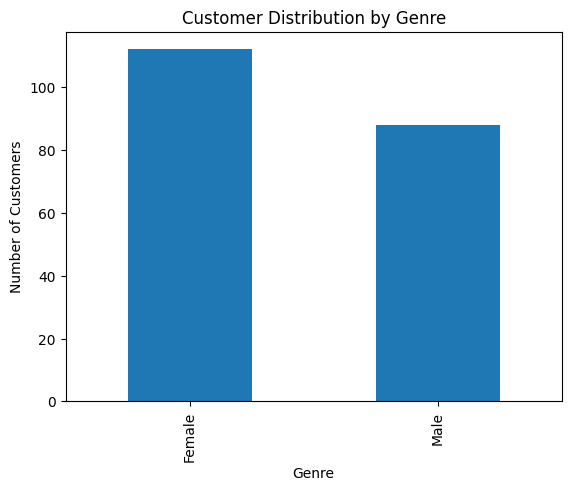

In [8]:
import matplotlib.pyplot as plt

df['Genre'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Customers')
plt.show()

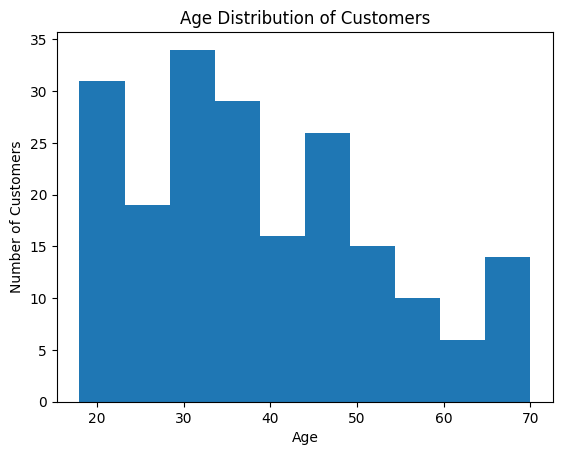

In [9]:
plt.hist(df['Age'], bins=10)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

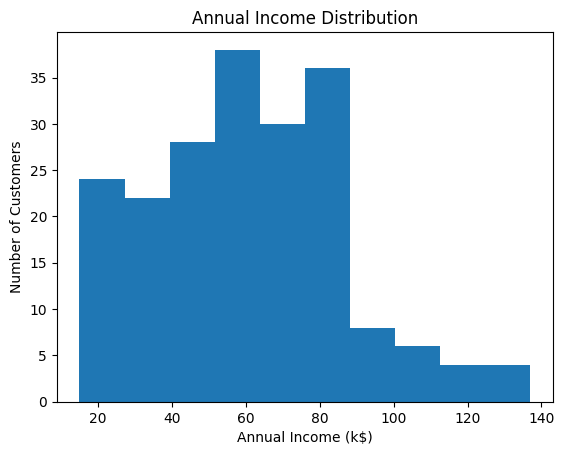

In [10]:
plt.hist(df['Annual Income (k$)'], bins=10)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')
plt.show()

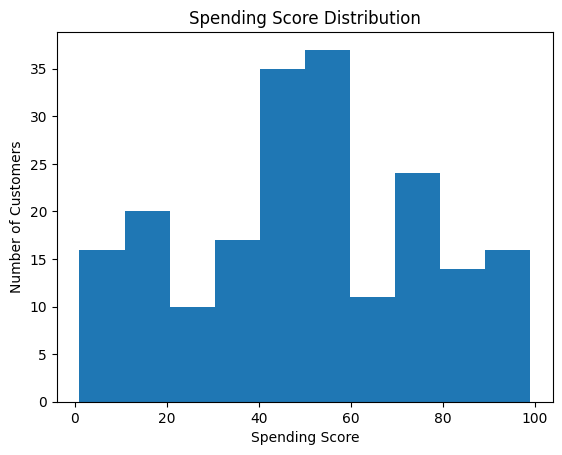

In [11]:
plt.hist(df['Spending Score (1-100)'], bins=10)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')
plt.show()

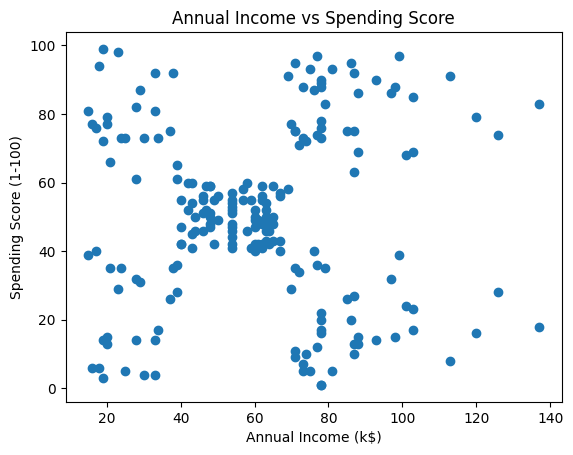

In [12]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [13]:
df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [14]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [16]:
X.isnull().sum()

Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [23]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [21]:
X_scaled.mean(axis=0)

array([-2.13162821e-16, -1.46549439e-16])

In [39]:
from sklearn.cluster import KMeans

In [37]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

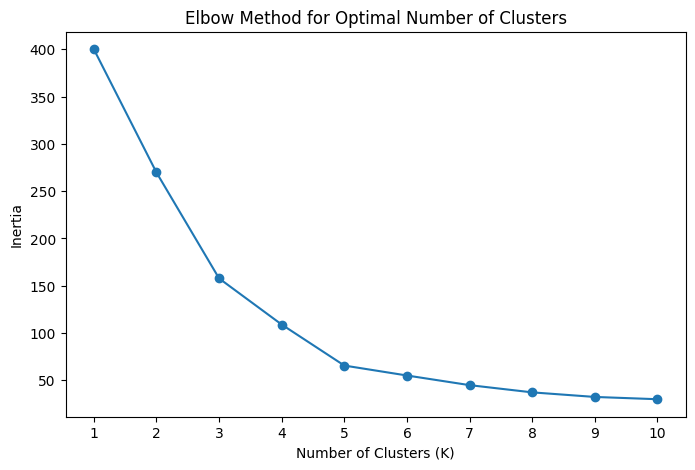

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))

plt.show()

In [38]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

In [40]:
df['Cluster'] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [41]:
df['Cluster'].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [43]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [44]:
cluster_size = df['Cluster'].value_counts().sort_index()

cluster_size

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [45]:
cluster_percentage = (
    df['Cluster'].value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_percentage

Cluster
0    40.5
1    19.5
2    11.0
3    17.5
4    11.5
Name: proportion, dtype: float64

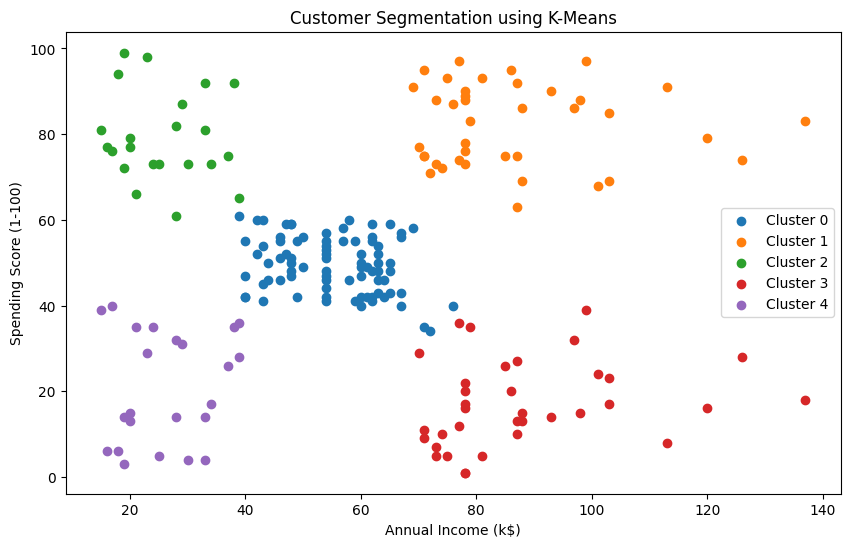

In [46]:
plt.figure(figsize=(10, 6))

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

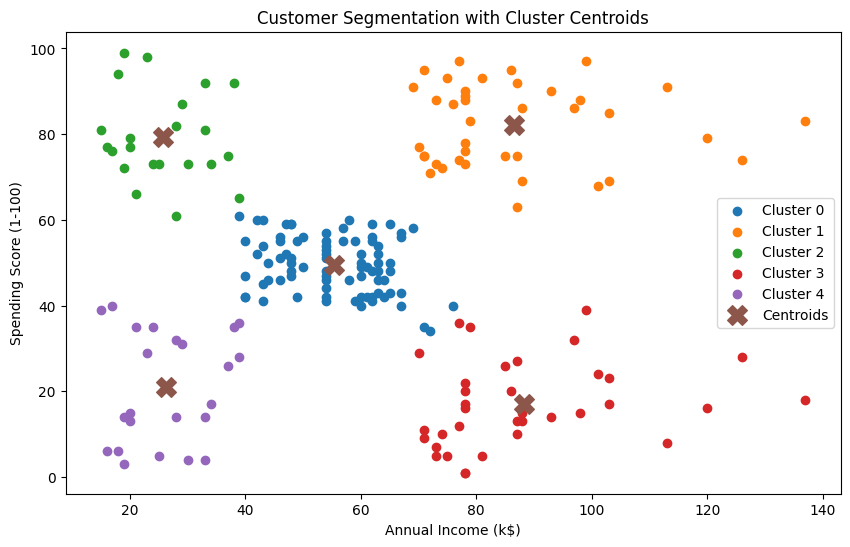

In [47]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))

for cluster in sorted(df['Cluster'].unique()):
    cluster_data = df[df['Cluster'] == cluster]
    
    plt.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {cluster}'
    )

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.title('Customer Segmentation with Cluster Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [48]:
# Cluster-wise summary
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

cluster_summary

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [49]:
# Assign meaningful segment names to clusters

cluster_names = {
    0: 'Average Customers',
    1: 'High-Value Customers',
    2: 'High-Spending, Low-Income',
    3: 'High-Income, Low-Spending',
    4: 'Low-Value Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

df[['Cluster', 'Customer Segment']].head()

,Cluster,Customer Segment
0,4,Low-Value Customers
1,2,"High-Spending, Low-Income"
2,4,Low-Value Customers
3,2,"High-Spending, Low-Income"
4,4,Low-Value Customers


In [50]:
# Count customers in each segment

segment_counts = df['Customer Segment'].value_counts()

segment_counts

Customer Segment
Average Customers            81
High-Value Customers         39
High-Income, Low-Spending    35
Low-Value Customers          23
High-Spending, Low-Income    22
Name: count, dtype: int64

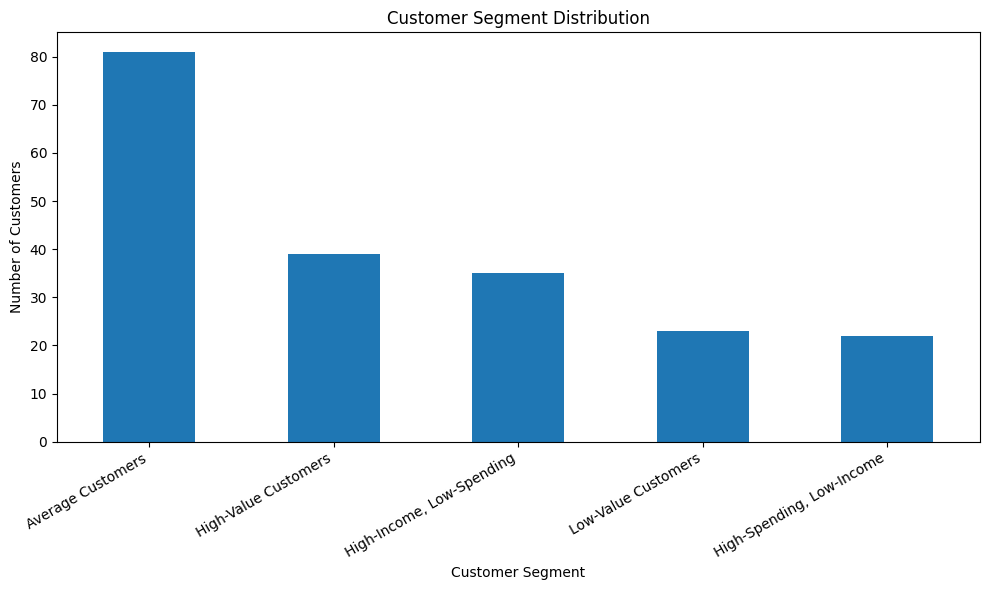

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

segment_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [53]:
# Final customer segment summary

final_summary = cluster_summary.copy()

final_summary['Customer Segment'] = final_summary.index.map(cluster_names)

# Get customer count using Cluster number
cluster_counts = df['Cluster'].value_counts().sort_index()

final_summary['Customer Count'] = final_summary.index.map(cluster_counts)

final_summary = final_summary[
    ['Customer Segment',
     'Annual Income (k$)',
     'Spending Score (1-100)',
     'Customer Count']
]

final_summary.sort_values('Customer Count', ascending=False)

,Customer Segment,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,Average Customers,55.296296,49.518519,81
1,High-Value Customers,86.538462,82.128205,39
3,"High-Income, Low-Spending",88.200000,17.114286,35
4,Low-Value Customers,26.304348,20.913043,23
2,"High-Spending, Low-Income",25.727273,79.363636,22


Key Insights

Average Customers are the largest segment with 81 customers, representing the largest portion of the customer base.
High-Value Customers (39 customers) have both high annual income and high spending scores, making them the most valuable target segment.
High-Income, Low-Spending customers (35 customers) have the highest average income but relatively low spending, indicating an opportunity for targeted engagement.
High-Spending, Low-Income customers (22 customers) show strong spending behavior despite lower income and may respond well to loyalty and retention strategies.
Low-Value Customers (23 customers) have both low income and low spending, making them a lower-priority segment.

Business Recommendations

Focus premium offers and loyalty programs on High-Value Customers.
Use personalized promotions to encourage High-Income, Low-Spending customers to increase their spending.
Retain High-Spending, Low-Income customers through discounts, loyalty rewards, and personalized offers.
Use cost-effective marketing strategies for Low-Value Customers.
Maintain regular engagement with the large Average Customer segment to move them toward higher-value segments.

Conclusion

The K-Means clustering model successfully segmented 200 customers into five distinct groups based on annual income and spending behavior. These segments provide actionable insights that can help businesses develop targeted marketing strategies, improve customer engagement, and prioritize high-value customer groups.

